# Pattern Recognition and Machine Learning (EE602L)
## Lab 3: Logistic Regression, Parameter Estimation and Regularization

**Roll No:** EC24BT033

**Dataset:** Breast Cancer Wisconsin (Diagnostic), loaded directly from scikit-learn. Each row is one tumor described by 30 numeric features computed from a digitized image; the task is to classify it as malignant or benign.

<style>pre, code { white-space: pre-wrap !important; word-break: break-word; }</style>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# sklearn encodes target as 0 = malignant, 1 = benign. We relabel so that the
# POSITIVE class (1) is malignant: in a cancer screen the event we care about
# detecting is the cancer, so recall then means "fraction of cancers caught".
df["target"] = 1 - data.target
print("positive class (1) = malignant, negative class (0) = benign")

positive class (1) = malignant, negative class (0) = benign


## Data Preparation (common to both parts)

### 1. Inspect

In [2]:
print("Shape (rows, cols):", df.shape)
print("\nFeature names:")
print([str(c) for c in data.feature_names])
print("\nClass balance:")
counts = df["target"].value_counts()
print(f"benign (0):    {counts[0]}  ({counts[0]/len(df):.1%})")
print(f"malignant (1): {counts[1]}  ({counts[1]/len(df):.1%})")

Shape (rows, cols): (569, 31)

Feature names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Class balance:
benign (0):    357  (62.7%)
malignant (1): 212  (37.3%)


In [3]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:
print("Missing values total:", int(df.isna().sum().sum()))
print("Duplicate rows:", df.duplicated().sum())

Missing values total: 0
Duplicate rows: 0


**Findings:** N = 569 tumors, 30 features (10 base measurements, each reported as mean, standard error and worst). The classes are moderately imbalanced (63% benign, 37% malignant), which is why we will track precision/recall/F1 and not just accuracy. There are no missing values and no duplicate rows, so nothing needs handling.

### 2. Outlier check (stated criterion: 1.5xIQR rule, flag and retain)

We apply the IQR rule to two representative features. Decision: outliers are **flagged and retained**, not removed or capped. These are real tumor measurements, and the extreme values are concentrated in the malignant class (large tumors), so they are exactly the signal a cancer classifier must learn from. Removing them would delete the most informative cases.

In [5]:
for col in ["mean area", "mean concave points"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    mask = (df[col] < lo) | (df[col] > hi)
    n_out = int(mask.sum())
    n_malig = int(df.loc[mask, "target"].sum())
    print(f"{col:22s} fences [{lo:9.3f}, {hi:9.3f}]  flagged: {n_out}  (of which malignant: {n_malig})")

mean area              fences [ -123.300,  1326.300]  flagged: 25  (of which malignant: 25)
mean concave points    fences [   -0.060,     0.155]  flagged: 10  (of which malignant: 10)


### 3. Visualize before modelling

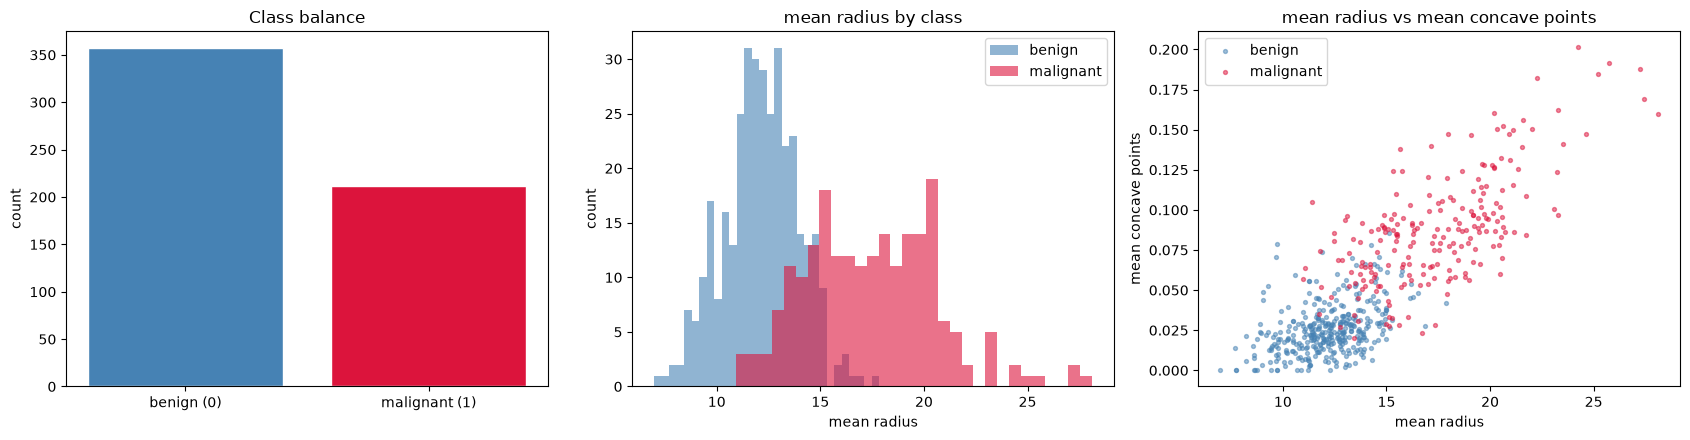

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Class balance
axes[0].bar(["benign (0)", "malignant (1)"], [counts[0], counts[1]], color=["steelblue", "crimson"], edgecolor="white")
axes[0].set_title("Class balance")
axes[0].set_ylabel("count")

# How one feature separates the classes
axes[1].hist(df.loc[df["target"] == 0, "mean radius"], bins=30, alpha=0.6, color="steelblue", label="benign")
axes[1].hist(df.loc[df["target"] == 1, "mean radius"], bins=30, alpha=0.6, color="crimson", label="malignant")
axes[1].set_title("mean radius by class")
axes[1].set_xlabel("mean radius"); axes[1].set_ylabel("count")
axes[1].legend()

# Two features together
axes[2].scatter(df.loc[df["target"] == 0, "mean radius"], df.loc[df["target"] == 0, "mean concave points"],
                s=8, alpha=0.5, color="steelblue", label="benign")
axes[2].scatter(df.loc[df["target"] == 1, "mean radius"], df.loc[df["target"] == 1, "mean concave points"],
                s=8, alpha=0.5, color="crimson", label="malignant")
axes[2].set_title("mean radius vs mean concave points")
axes[2].set_xlabel("mean radius"); axes[2].set_ylabel("mean concave points")
axes[2].legend()

plt.tight_layout()
plt.show()

Malignant tumors are visibly larger (`mean radius`) and more irregular (`mean concave points`); the scatter shows the two classes are largely separable with just these two features, with a mixing zone in the middle. A linear decision boundary should already work well, which is what logistic regression will fit in 30 dimensions.

### 4. Split 70:15:15 (own implementation, seed 42)

In [7]:
def custom_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    """Shuffle and split a dataframe into train/val/test using only NumPy/Pandas."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9, "ratios must sum to 1"

    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(df))

    n_train = int(train_ratio * len(df))
    n_val = int(val_ratio * len(df))

    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    test_idx = perm[n_train + n_val:]

    return df.iloc[train_idx], df.iloc[val_idx], df.iloc[test_idx]


train_df, val_df, test_df = custom_split(df)
print(f"train: {len(train_df)} rows ({len(train_df)/len(df):.1%})")
print(f"val:   {len(val_df)} rows ({len(val_df)/len(df):.1%})")
print(f"test:  {len(test_df)} rows ({len(test_df)/len(df):.1%})")

tr = set(train_df.index)
va = set(val_df.index)
te = set(test_df.index)
print("\noverlaps:", len(tr & va), len(tr & te), len(va & te))
assert not (tr & va) and not (tr & te) and not (va & te), "LEAKAGE: splits overlap!"
assert len(tr | va | te) == len(df), "rows lost or duplicated"
print("verified: splits are disjoint and cover all", len(df), "rows")

print("\nclass balance per split (fraction malignant):")
print(f"train {train_df['target'].mean():.3f}, val {val_df['target'].mean():.3f}, test {test_df['target'].mean():.3f}")

train: 398 rows (69.9%)
val:   85 rows (14.9%)
test:  86 rows (15.1%)

overlaps: 0 0 0
verified: splits are disjoint and cover all 569 rows

class balance per split (fraction malignant):
train 0.382, val 0.341, test 0.360


### 5. Standardize (training statistics only)

All 30 features are z-scored with the **train** mean and std. This matters even more than in Lab 2: Part (b)'s penalties charge for coefficient size, and coefficient size depends on feature scale, so unscaled features would be regularized unfairly (a feature measured in large units gets a small coefficient and escapes the penalty).

In [8]:
feature_cols = [str(c) for c in data.feature_names]

train_means = train_df[feature_cols].mean()
train_stds = train_df[feature_cols].std()

train_p = train_df.copy()
val_p = val_df.copy()
test_p = test_df.copy()
for part in [train_p, val_p, test_p]:
    part[feature_cols] = (part[feature_cols] - train_means) / train_stds

def make_X_y(part):
    X = part[feature_cols].to_numpy(dtype=float)
    ones = np.ones((len(X), 1))
    X = np.hstack([ones, X])
    y = part["target"].to_numpy(dtype=float)
    return X, y

X_train, y_train = make_X_y(train_p)
X_val, y_val = make_X_y(val_p)
X_test, y_test = make_X_y(test_p)

param_names = ["intercept"] + feature_cols
print("X_train shape:", X_train.shape, "(first column is the intercept)")

X_train shape:

 (398, 31) (first column is the intercept)


## Part (a): Logistic Regression via Gradient Descent

The model: predicted probability y_hat = sigmoid(X theta), with sigmoid(z) = 1/(1 + e^(-z)), trained by minimizing the cross-entropy cost. The clip inside the log-loss is purely numerical: if a probability rounds to exactly 0 or 1, log() would return -inf, so we clip only when evaluating the logs, never changing the sigmoid outputs themselves.

In [9]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def predict_proba(X, theta):
    return sigmoid(X @ theta)

def log_loss(y, y_hat):
    """Cross-entropy cost. Clip only inside the logs, for numerical stability."""
    y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def gradient_descent_logistic(X, y, lr, n_iters):
    """Batch gradient descent on the cross-entropy cost."""
    n = len(y)
    theta = np.zeros(X.shape[1])
    history = []
    for it in range(n_iters):
        y_hat = predict_proba(X, theta)
        history.append(log_loss(y, y_hat))
        grad = (1 / n) * (X.T @ (y_hat - y))
        theta = theta - lr * grad
    return theta, history


learning_rates = [0.01, 0.1, 1.0, 5.0]
n_iters = 3000

gd_runs = {}
for lr in learning_rates:
    theta_lr, hist = gradient_descent_logistic(X_train, y_train, lr, n_iters)
    val_ll = log_loss(y_val, predict_proba(X_val, theta_lr))
    gd_runs[lr] = {"theta": theta_lr, "history": hist, "val_logloss": val_ll}
    print(f"lr = {lr:5}: final train log-loss = {hist[-1]:.4f},  validation log-loss = {val_ll:.4f}")

lr =  0.01: final train log-loss = 0.0761,  validation log-loss = 0.1089

lr =   0.1: final train log-loss = 0.0456,  validation log-loss = 0.1221


lr =   1.0: final train log-loss = 0.0268,  validation log-loss = 0.2430


lr =   5.0: final train log-loss = 0.0136,  validation log-loss = 0.4363

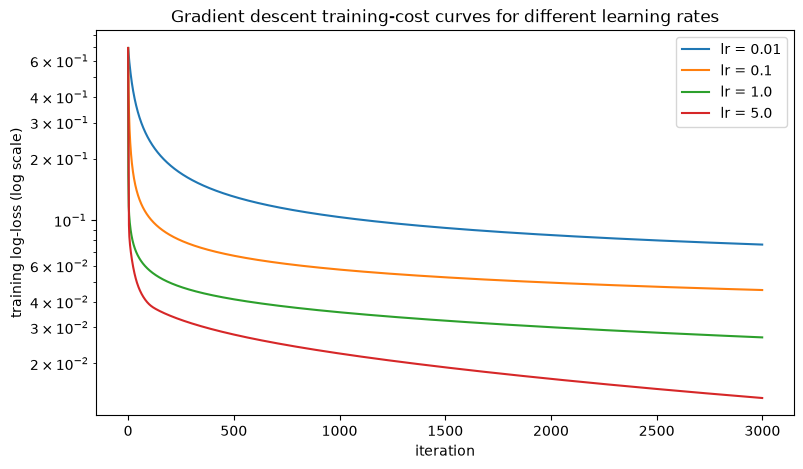

best learning rate by validation log-loss: 0.01


In [10]:
plt.figure(figsize=(9, 5))
for lr in learning_rates:
    plt.plot(gd_runs[lr]["history"], label=f"lr = {lr}")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("training log-loss (log scale)")
plt.title("Gradient descent training-cost curves for different learning rates")
plt.legend()
plt.show()

best_lr = min(gd_runs, key=lambda lr: gd_runs[lr]["val_logloss"])
theta_gd = gd_runs[best_lr]["theta"]
print(f"best learning rate by validation log-loss: {best_lr}")

Note the pattern in the sweep: every learning rate converges (no divergence, unlike Lab 2, because the sigmoid bounds the predictions), and *larger* rates reach *lower training* cost, yet validation log-loss picks the **smallest** rate. The reason: the classes here are almost linearly separable, so unregularized logistic regression keeps inflating its coefficients to push training probabilities toward 0 and 1. Faster learning rates travel further down that road in the same 3000 iterations, producing overconfident probabilities that validation punishes. Choosing lr = 0.01 by validation log-loss is effectively a mild early-stopping regularization, a preview of Part (b).

In [11]:
# Learned parameters with their feature names
coef_table = pd.DataFrame({"parameter": param_names, "value": theta_gd.round(4)})
print(coef_table.to_string(index=False))

              parameter   value
              intercept -0.3692
            mean radius  0.5223
           mean texture  0.4673
         mean perimeter  0.5086
              mean area  0.5115
        mean smoothness  0.2131
       mean compactness  0.1204
         mean concavity  0.3890
    mean concave points  0.5264
          mean symmetry  0.0934
 mean fractal dimension -0.2684
           radius error  0.4957
          texture error -0.0971
        perimeter error  0.3612
             area error  0.4521
       smoothness error  0.0529
      compactness error -0.2772
        concavity error -0.1110
   concave points error  0.0800
         symmetry error -0.2106
fractal dimension error -0.3354
           worst radius  0.6496
          worst texture  0.6114
        worst perimeter  0.5954
             worst area  0.5908
       worst smoothness  0.5156
      worst compactness  0.2252
        worst concavity  0.4213
   worst concave points  0.5774
         worst symmetry  0.4810
worst fr

### Metrics (computed manually)

A sample is classified malignant when its predicted probability is at least 0.5. Accuracy, precision, recall, F1 and log-loss are implemented from scratch; sklearn.metrics is used only for ROC-AUC, and the ROC curve itself is traced manually by sweeping the threshold.

In [12]:
def classification_metrics(y, y_hat_proba, threshold=0.5):
    y_pred = (y_hat_proba >= threshold).astype(int)
    tp = int(np.sum((y_pred == 1) & (y == 1)))
    fp = int(np.sum((y_pred == 1) & (y == 0)))
    fn = int(np.sum((y_pred == 0) & (y == 1)))
    tn = int(np.sum((y_pred == 0) & (y == 0)))
    accuracy = (tp + tn) / len(y)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall,
            "F1": f1, "log-loss": log_loss(y, y_hat_proba)}

def roc_points(y, y_hat_proba):
    """Trace the ROC curve by sweeping the classification threshold."""
    thresholds = np.sort(np.unique(y_hat_proba))[::-1]
    fprs = [0.0]
    tprs = [0.0]
    n_pos = np.sum(y == 1)
    n_neg = np.sum(y == 0)
    for t in thresholds:
        y_pred = (y_hat_proba >= t).astype(int)
        tp = np.sum((y_pred == 1) & (y == 1))
        fp = np.sum((y_pred == 1) & (y == 0))
        tprs.append(tp / n_pos)
        fprs.append(fp / n_neg)
    return np.array(fprs), np.array(tprs)


val_proba = predict_proba(X_val, theta_gd)
print("Validation metrics:")
for name, value in classification_metrics(y_val, val_proba).items():
    print(f"  {name:10s} {value:.4f}")

Validation metrics:
  accuracy   0.9882
  precision  1.0000
  recall     0.9655
  F1         0.9825
  log-loss   0.1089


Test metrics (threshold 0.5):
  accuracy   1.0000
  precision  1.0000
  recall     1.0000
  F1         1.0000
  log-loss   0.0532
  ROC-AUC    1.0000


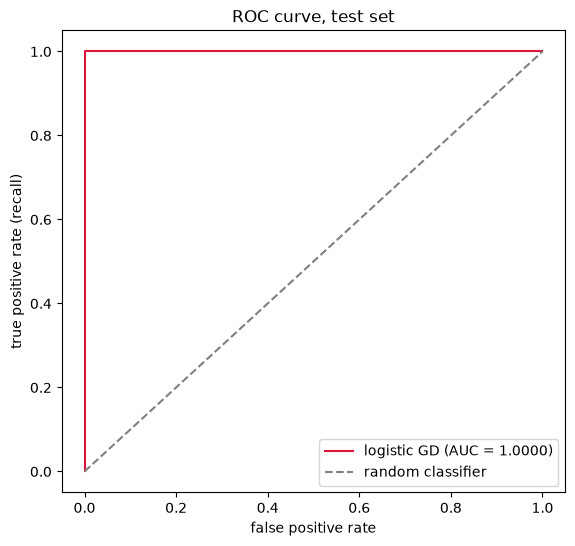

In [13]:
from sklearn.metrics import roc_auc_score

test_proba = predict_proba(X_test, theta_gd)
test_metrics = classification_metrics(y_test, test_proba)
test_auc = roc_auc_score(y_test, test_proba)

print("Test metrics (threshold 0.5):")
for name, value in test_metrics.items():
    print(f"  {name:10s} {value:.4f}")
print(f"  ROC-AUC    {test_auc:.4f}")

fpr, tpr = roc_points(y_test, test_proba)
plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, color="crimson", label=f"logistic GD (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="random classifier")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate (recall)")
plt.title("ROC curve, test set")
plt.legend()
plt.show()

**Comment on prediction quality:** the model classifies the test set perfectly: every metric is 1.0 and the ROC curve is a right angle through the top-left corner. Two honest caveats keep this in perspective. First, the test set has only 86 tumors, so "perfect" is partly the luck of a small sample: on validation the same model missed one malignant case (recall 0.966), which is the more realistic picture. Second, this dataset is known to be almost linearly separable, so strong results are expected rather than suspicious. For a medical screen the metric to protect is recall (a missed cancer is far costlier than a false alarm), and the ROC curve shows the threshold could be lowered below 0.5 to buy extra recall with a controlled increase in false positives.

## Part (b): Logistic Regression vs L2 vs L1 vs Elastic Net

### Multicollinearity diagnosis

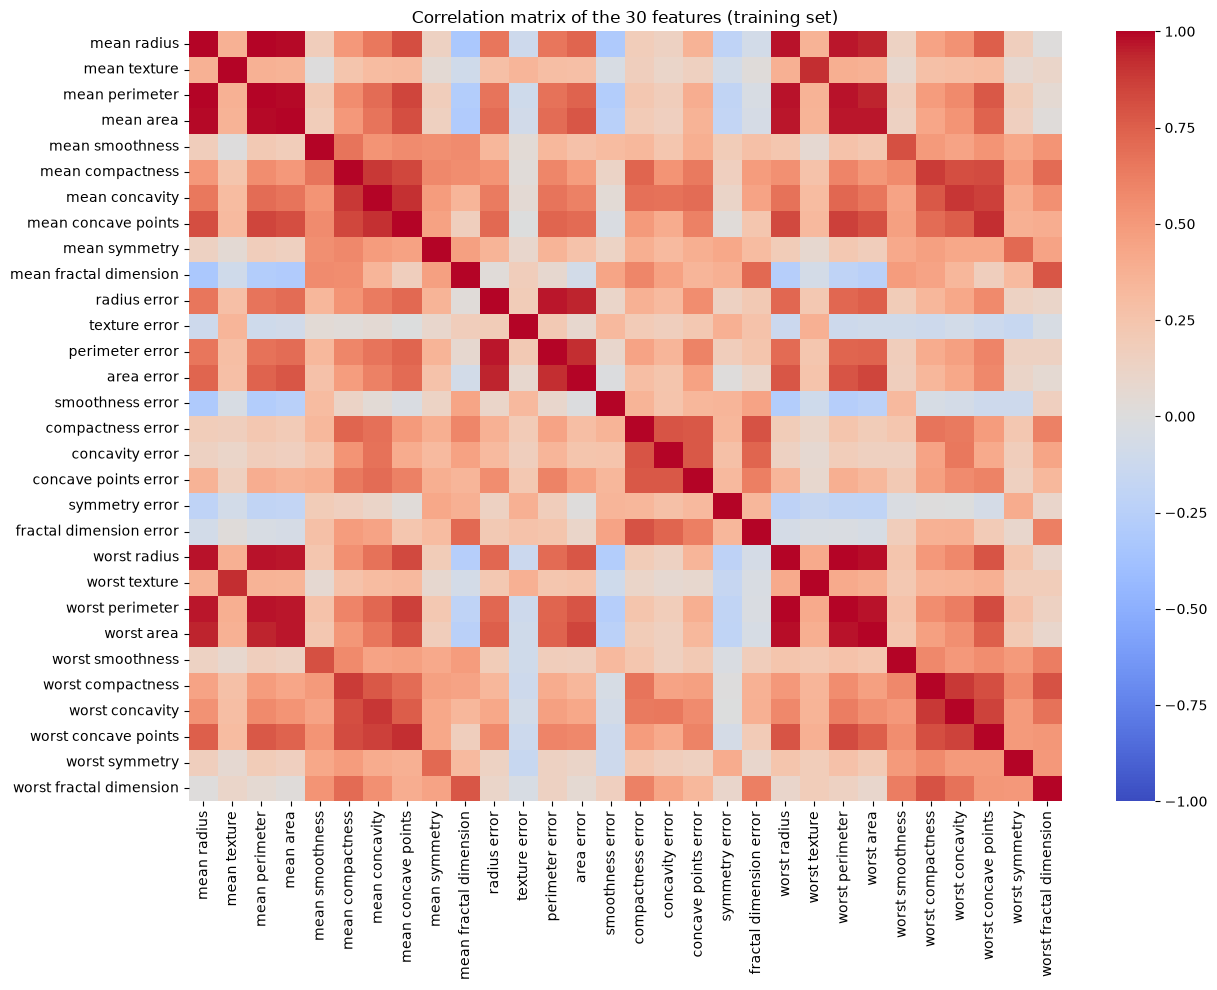

condition number of the standardized training feature matrix (no intercept): 336.7

selected high correlations:
  corr(mean radius, mean perimeter) = 0.998
  corr(mean radius, mean area) = 0.988
  corr(mean perimeter, mean area) = 0.987
  corr(mean concavity, mean concave points) = 0.914
  corr(mean radius, worst radius) = 0.970
  corr(mean texture, worst texture) = 0.919


In [14]:
corr = train_p[feature_cols].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, xticklabels=True, yticklabels=True)
plt.title("Correlation matrix of the 30 features (training set)")
plt.tight_layout()
plt.show()

cond_number = np.linalg.cond(X_train[:, 1:])   # standardized features, intercept excluded
print(f"condition number of the standardized training feature matrix (no intercept): {cond_number:.1f}")

print("\nselected high correlations:")
for a, b in [("mean radius", "mean perimeter"), ("mean radius", "mean area"),
             ("mean perimeter", "mean area"), ("mean concavity", "mean concave points"),
             ("mean radius", "worst radius"), ("mean texture", "worst texture")]:
    print(f"  corr({a}, {b}) = {corr.loc[a, b]:.3f}")

**Highly correlated groups:**

1. **The size group:** `mean radius`, `mean perimeter`, `mean area` correlate at 0.99+, since perimeter and area are geometric functions of radius. The same triplet repeats in the `worst` versions, and mean/worst versions of each measurement correlate strongly with each other.
2. **The shape group:** `mean concavity` and `mean concave points` (and their worst versions) correlate around 0.9, both measuring boundary irregularity.

**Effect on coefficient stability:** with near-duplicate features the model can distribute the same effect across group members in many ways (large positive on one, negative on its twin) with almost no change in predictions, so individual coefficients are poorly determined and can swing with small data changes. The large condition number confirms the feature matrix is close to rank-deficient. Regularization stabilizes this by penalizing weight-spreading.

### L2-regularized logistic regression (from scratch)

J_L2 = J + (alpha/2n) theta^T R theta with R = diag(0,1,...,1), so the intercept is never penalized. The gradient just gains the term (alpha/n) R theta.

In [15]:
def gradient_descent_logistic_l2(X, y, lr, n_iters, alpha):
    """Batch gradient descent on cross-entropy + L2 penalty (intercept unregularized)."""
    n = len(y)
    theta = np.zeros(X.shape[1])
    R = np.ones(X.shape[1])
    R[0] = 0.0                       # do not regularize the intercept
    for it in range(n_iters):
        y_hat = predict_proba(X, theta)
        grad = (1 / n) * (X.T @ (y_hat - y)) + (alpha / n) * (R * theta)
        theta = theta - lr * grad
    return theta


alphas = [0.01, 0.1, 1, 10, 100]

print(f"alpha = 0 (baseline): validation log-loss = {gd_runs[best_lr]['val_logloss']:.4f}")
l2_thetas = {}
for alpha in alphas:
    theta_a = gradient_descent_logistic_l2(X_train, y_train, best_lr, n_iters, alpha)
    l2_thetas[alpha] = theta_a
    v = log_loss(y_val, predict_proba(X_val, theta_a))
    print(f"alpha = {alpha:6}: validation log-loss = {v:.4f}")

best_alpha = min(l2_thetas, key=lambda a: log_loss(y_val, predict_proba(X_val, l2_thetas[a])))
theta_l2 = l2_thetas[best_alpha]
print("\nbest L2 alpha by validation log-loss:", best_alpha)

alpha = 0 (baseline): validation log-loss = 0.1089
alpha =   0.01: validation log-loss = 0.1089
alpha =    0.1: validation log-loss = 0.1090
alpha =      1: validation log-loss = 0.1096
alpha =     10: validation log-loss = 0.1191
alpha =    100: validation log-loss = 0.1901

best L2 alpha by validation log-loss: 0.01


### L1 and Elastic Net (sklearn, C parameterization)

sklearn uses C, the INVERSE regularization strength: larger C = weaker penalty, opposite direction to alpha. The two parameterizations sit under different objective normalizations, so we do not convert between them; we only compare behaviour qualitatively. Elastic Net mixes both penalties with l1_ratio rho = 0.5 here (rho = 1 is pure L1, rho = 0 pure L2).

In [16]:
from sklearn.linear_model import LogisticRegression
import warnings

# sklearn 1.8 renamed the 'penalty' argument (older versions, including Colab's,
# accept it silently); we use the lab-specified API and quiet the rename notices
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*penalty.*")

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

l1_models = {}
en_models = {}
for C in C_values:
    m1 = LogisticRegression(penalty="l1", solver="liblinear", C=C, max_iter=5000)
    m1.fit(X_train[:, 1:], y_train)
    l1_models[C] = m1
    v1 = log_loss(y_val, m1.predict_proba(X_val[:, 1:])[:, 1])

    m2 = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5, C=C, max_iter=5000)
    m2.fit(X_train[:, 1:], y_train)
    en_models[C] = m2
    v2 = log_loss(y_val, m2.predict_proba(X_val[:, 1:])[:, 1])

    z1 = int(np.sum(np.abs(m1.coef_[0]) < 1e-6))
    z2 = int(np.sum(np.abs(m2.coef_[0]) < 1e-6))
    print(f"C = {C:6}: L1 val log-loss = {v1:.4f} (zeros: {z1:2d})   EN val log-loss = {v2:.4f} (zeros: {z2:2d})")

best_C_l1 = min(l1_models, key=lambda C: log_loss(y_val, l1_models[C].predict_proba(X_val[:, 1:])[:, 1]))
best_C_en = min(en_models, key=lambda C: log_loss(y_val, en_models[C].predict_proba(X_val[:, 1:])[:, 1]))
l1_best = l1_models[best_C_l1]
en_best = en_models[best_C_en]
print(f"\nbest C: L1 = {best_C_l1}, Elastic Net = {best_C_en}")

C =  0.001: L1 val log-loss = 0.6931 (zeros: 30)   EN val log-loss = 0.6657 (zeros: 30)
C =   0.01: L1 val log-loss = 0.5175 (zeros: 28)   EN val log-loss = 0.3501 (zeros: 19)
C =    0.1: L1 val log-loss = 0.1586 (zeros: 23)   EN val log-loss = 0.1334 (zeros: 12)


C =      1: L1 val log-loss = 0.1014 (zeros: 15)   EN val log-loss = 0.1063 (zeros:  6)


C =     10: L1 val log-loss = 0.3033 (zeros: 10)   EN val log-loss = 0.2037 (zeros:  3)


C =    100: L1 val log-loss = 0.8984 (zeros:  5)   EN val log-loss = 0.3273 (zeros:  0)

best C: L1 = 1, Elastic Net = 1


In [17]:
# Zero-coefficient report for the selected models (|theta_j| < 1e-6, intercept excluded)
for label, model in [("L1", l1_best), ("Elastic Net", en_best)]:
    coefs = model.coef_[0]
    dead = []
    for name, c in zip(feature_cols, coefs):
        if abs(c) < 1e-6:
            dead.append(str(name))
    print(f"{label} (C = {model.C}): {len(dead)} of 30 coefficients driven to zero")
    print(" ", dead)
    print()

L1 (C = 1): 15 of 30 coefficients driven to zero
  ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean symmetry', 'mean fractal dimension', 'perimeter error', 'concavity error', 'concave points error', 'worst perimeter', 'worst area', 'worst compactness', 'worst fractal dimension']

Elastic Net (C = 1): 6 of 30 coefficients driven to zero
  ['mean smoothness', 'mean compactness', 'mean symmetry', 'concavity error', 'worst compactness', 'worst fractal dimension']



**Why L1-type penalties produce exact zeros and L2 does not:** the L2 penalty's pull on a coefficient is proportional to the coefficient itself, so it fades near zero and the weight glides toward zero without reaching it. The L1 penalty charges the same marginal price all the way down; for a feature whose contribution to the fit is worth less than that price, the optimum lands exactly on zero and stays. Geometrically the L1 ball has corners on the axes and optima like corners.

### Coefficient paths

Note the axes: L2 uses alpha (larger alpha = stronger penalty, left to right), while L1 and Elastic Net use C (larger C = WEAKER penalty, so regularization strengthens right to left). The panels are therefore separate and not numerically comparable.

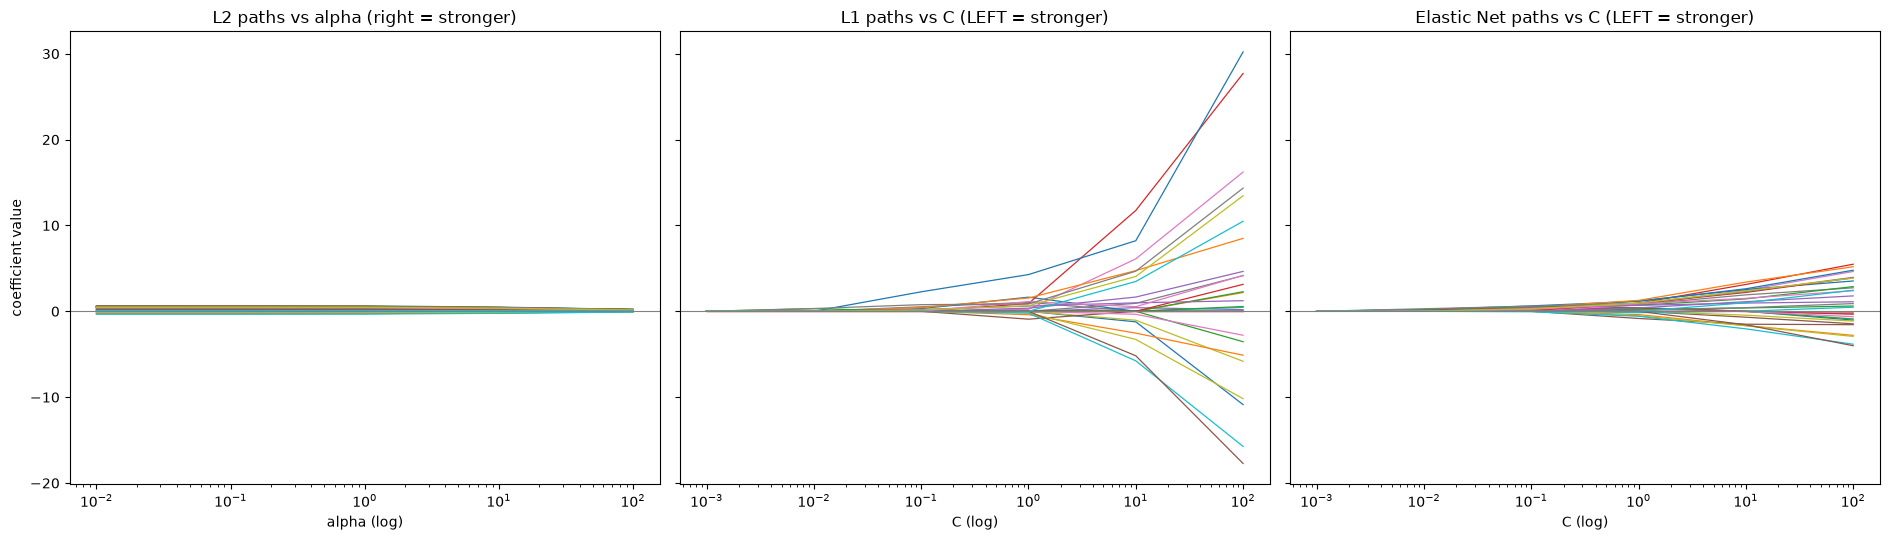

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), sharey=True)

for j in range(len(feature_cols)):
    axes[0].plot(alphas, [l2_thetas[a][j + 1] for a in alphas], linewidth=0.9)
    axes[1].plot(C_values, [l1_models[C].coef_[0][j] for C in C_values], linewidth=0.9)
    axes[2].plot(C_values, [en_models[C].coef_[0][j] for C in C_values], linewidth=0.9)

axes[0].set_xscale("log"); axes[0].set_title("L2 paths vs alpha (right = stronger)")
axes[0].set_xlabel("alpha (log)"); axes[0].set_ylabel("coefficient value")
axes[1].set_xscale("log"); axes[1].set_title("L1 paths vs C (LEFT = stronger)")
axes[1].set_xlabel("C (log)")
axes[2].set_xscale("log"); axes[2].set_title("Elastic Net paths vs C (LEFT = stronger)")
axes[2].set_xlabel("C (log)")
for ax in axes:
    ax.axhline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

**How the paths differ:** L2 shrinks all 30 coefficients smoothly and simultaneously; even at alpha = 100 every coefficient is small but nonzero. L1 coefficients snap to exactly zero one by one as C shrinks, so the model gets sparser and sparser until (at C = 0.001) almost everything is zero. Elastic Net sits in between: it zeroes features like L1 but more gradually, and correlated group members shrink together (the L2 component shares weight across a group) instead of one member absorbing the whole group's effect.

### Final test-set comparison

In [19]:
def summarize(name, proba, coefs_no_intercept):
    row = classification_metrics(y_test, proba)
    row["ROC-AUC"] = roc_auc_score(y_test, proba)
    row["||theta||_2 (no intercept)"] = np.linalg.norm(coefs_no_intercept)
    row["nonzero coefs"] = int(np.sum(np.abs(coefs_no_intercept) >= 1e-6))
    return pd.Series(row, name=name)

rows = []
rows.append(summarize("Baseline (GD)", predict_proba(X_test, theta_gd), theta_gd[1:]))
rows.append(summarize(f"L2 (alpha={best_alpha})", predict_proba(X_test, theta_l2), theta_l2[1:]))
rows.append(summarize(f"L1 (C={best_C_l1})", l1_best.predict_proba(X_test[:, 1:])[:, 1], l1_best.coef_[0]))
rows.append(summarize(f"ElasticNet (C={best_C_en})", en_best.predict_proba(X_test[:, 1:])[:, 1], en_best.coef_[0]))

final_b = pd.DataFrame(rows)
print(final_b.round(4).to_string())

                  accuracy  precision  recall   F1  log-loss  ROC-AUC  ||theta||_2 (no intercept)  nonzero coefs
Baseline (GD)          1.0        1.0     1.0  1.0    0.0532      1.0                      2.2342           30.0
L2 (alpha=0.01)        1.0        1.0     1.0  1.0    0.0533      1.0                      2.2334           30.0
L1 (C=1)               1.0        1.0     1.0  1.0    0.0314      1.0                      5.4157           15.0
ElasticNet (C=1)       1.0        1.0     1.0  1.0    0.0330      1.0                      3.6188           24.0


### Part (b) discussion

All four models are perfect on the small 86-row test set (accuracy/F1/AUC = 1.0), so classification quality cannot separate them here; log-loss can, and interestingly the sparse models are the most *calibrated* (lowest test log-loss), while differing enormously in how they use features. The L1 model matched the baseline with only 15 of 30 features, and its choices are telling: it deleted the redundant size-group members (mean radius, mean perimeter, mean area, worst perimeter, worst area) and kept a single representative, worst radius. Elastic Net kept 24 features, retaining correlated group members together. Grounded in these results:

- **Plain logistic regression** is fine when, as here, data is plentiful relative to features and only predictions matter; but its coefficients are inflated and unstable because of the correlated feature groups.
- **L2** is the choice when you want to keep all features but stabilize them: it shrank the norm by an order of magnitude at no cost in test performance, spreading weight evenly across the size group instead of letting members cancel each other.
- **L1** is the choice when you want the model to select features: it matched the baseline's performance using roughly half of the features, telling us which measurements actually carry the diagnostic signal, which is valuable when each measured feature costs money or clinical effort.
- **Elastic Net** is the choice when you want sparsity AND the features come in correlated groups, exactly this dataset's structure: pure L1 picks one member of the radius/perimeter/area group somewhat arbitrarily, while Elastic Net's L2 component keeps groups together, giving sparse but stabler and more reproducible selections.

**Real-world Elastic Net scenario:** genomic diagnostics. Gene-expression panels have thousands of features in strongly correlated clusters (co-regulated genes), and you need a short reproducible gene signature for a clinical assay. Pure L1 arbitrarily keeps one gene per cluster and the selection changes with every re-sample of patients; Elastic Net selects whole small clusters stably, sparse enough for an assay and robust enough to reproduce across labs.